# 05_02. Hydrography Data Integration and Validation

## 1. Introduction

Hydrography datasets are commonly available from multiple levels of government, including municipal, regional, provincial, and federal organizations. Although these datasets often describe the same rivers, creeks, lakes, ponds, and reservoirs, they are rarely identical. Differences in spatial resolution, collection methods, update frequency, feature classification, attribute schemas, naming conventions, and geometric precision can make direct comparison and integration surprisingly difficult.

Rather than assuming that one dataset is inherently superior to another, this notebook develops a systematic workflow for evaluating, standardizing, and integrating multiple hydrography datasets into a single database suitable for ecological modelling.

The workflow extends well beyond simple visualization. It includes geometry validation, coordinate reference system verification, feature classification, schema standardization, duplicate detection, feature matching, metadata reconciliation, and dataset integration. Each step improves the consistency, traceability, and reliability of the final hydrography layer before it is used by later ecological models.

Although this notebook focuses on hydrography within Waterloo Region, the methodology is intentionally general and can be applied to geographic datasets from other jurisdictions or environmental domains.

### Objectives

The objectives of this notebook are to:

- load hydrography datasets from multiple government sources,
- validate and repair spatial geometries,
- standardize feature classifications,
- standardize attribute schemas,
- normalize naming conventions,
- verify coordinate reference systems,
- visualize and compare individual hydrography datasets,
- identify duplicate or overlapping features,
- evaluate candidate feature matches,
- reconcile conflicting metadata,
- construct a unified hydrography dataset for future ecological analyses.

Rather than relying on any single government dataset, the final product represents a standardized hydrography layer that combines the strengths of multiple data sources while documenting every processing decision throughout the integration workflow.

### Limitations

Although the Region of Waterloo and its municipalities provide an extensive collection of hydrographic datasets, preliminary analysis reveals that the available data are neither complete nor fully standardized. For example, the Regional hydrography datasets currently contain rivers and creeks but do not include lakes or ponds. Some municipalities, such as Cambridge and the surrounding townships of Wilmot, Wellesley, Woolwich, and North Dumfries, currently provide little or no municipal hydrography data, meaning these areas rely almost entirely on the Regional datasets.

As a result, no individual dataset should be considered a complete representation of the Region's hydrography. Instead, a more comprehensive dataset can be produced by carefully integrating information from multiple sources. This notebook represents the first stage of that process, with future work comparing the completed municipal and regional dataset against provincial sources such as the Ontario Hydro Network.

Hydrography integration presents several technical challenges. Water features change over time due to natural processes such as erosion, flooding, seasonal water levels, and human modification. Different organizations may also map the same feature using different collection methods, positional accuracies, or update schedules, resulting in legitimate differences in geometry even when describing the same real-world feature.

Matching features across datasets therefore requires multiple sources of evidence. Where available, feature names provide strong evidence that two records describe the same water feature. Spatial overlap provides additional evidence, although it must be interpreted carefully. For example, comparing rivers against lakes or ponds may produce geometric intersections that represent genuine hydrological relationships rather than duplicate observations. Consequently, comparisons should be performed between similar feature types whenever possible.

Even after standardization, some water features remain difficult to reconcile. Many smaller streams, ponds, and wetlands are unnamed, while others may be segmented differently between datasets. Automated matching therefore cannot always determine whether two features should be merged. In these situations, this workflow identifies uncertain matches for manual review rather than forcing potentially incorrect decisions.

The goal of this notebook is therefore not simply to merge datasets automatically, but to develop a transparent and reproducible integration workflow that maximizes data quality while clearly documenting any remaining uncertainty.

## 2. Import Libraries

This notebook relies primarily on GeoPandas and Shapely for geographic data processing.

Additional libraries are used for numerical analysis, data manipulation, visualization, and file management.

Throughout the notebook, processing steps are organized so that each transformation can be inspected and reproduced independently.

In [1]:
# ============================================================
# Standard Library
# ============================================================

from pathlib import Path

# ============================================================
# Numerical Computing
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# GIS Libraries
# ============================================================

import geopandas as gpd

from shapely.ops import unary_union

# ============================================================
# Plotting
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# Display Options
# ============================================================

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (8, 8)

## 3. Load Hydrography Datasets

The hydrography datasets used throughout this notebook originate from multiple government organizations.

Because each organization structures and classifies its data differently, every dataset is loaded independently before any processing begins.

No assumptions are made at this stage regarding compatibility between datasets. The purpose of this section is simply to establish a reproducible collection of source data that will be evaluated throughout the remainder of the notebook.

The datasets currently include:

### Municipal

- Waterloo Creeks
- Waterloo Water Bodies
- Kitchener Rivers, Creeks, Ponds and Lakes

### Regional

- Waterloo Region Creeks
- Waterloo Region Rivers

Additional provincial datasets from the Ontario Hydro Network will be incorporated later in the project for comparison and validation.

In [88]:
# ============================================================
# Project Paths
# ============================================================

project_root = Path("../../")

data_dir = project_root / "data"

geohub_dir = data_dir / "Geohub"

municipal_dir = geohub_dir / "Municipal"

regional_dir = geohub_dir / "Regional" / "Waterloo"

elevation_dir = data_dir / "Elevation"

In [89]:
# ============================================================
# Municipal Datasets
# ============================================================

waterloo_creeks = gpd.read_file(
    municipal_dir / "Waterloo" / "Creeks.geojson"
)

waterloo_water = gpd.read_file(
    municipal_dir / "Waterloo" / "Water_Bodies.geojson"
)

kitchener_hydro = gpd.read_file(
    municipal_dir / "Kitchener" /
    "Rivers_Creeks_Ponds_and_Lakes.geojson"
)

In [90]:
# ============================================================
# Regional Datasets
# ============================================================

regional_creeks = gpd.read_file(
    regional_dir / "Creeks.geojson"
)

regional_rivers = gpd.read_file(
    regional_dir / "Rivers.geojson"
)

In [91]:
datasets = {
    "Waterloo Creeks": waterloo_creeks,
    "Waterloo Water Bodies": waterloo_water,
    "Kitchener Hydrography": kitchener_hydro,
    "Regional Creeks": regional_creeks,
    "Regional Rivers": regional_rivers,
}

## 4. Geometry Validation and Repair

### 4.1 Definition of Invalid Geometry

Before datasets can be compared or merged, their geometries must be validated.

Spatial datasets occasionally contain invalid geometries resulting from self-intersections, improperly closed polygons, duplicate vertices, or other topological inconsistencies. Although these problems are often invisible during plotting, they may cause spatial operations such as intersections, unions, dissolves, buffering, and overlays to fail.

Each dataset is therefore inspected for invalid geometries.

### 4.2 Repairing Invalid Geometry

Whenever invalid features are detected, they are repaired automatically using Shapely's geometry validation routines. The repaired geometries replace the originals so that every subsequent processing step operates on valid spatial data.

The number of repaired geometries is reported for each dataset to document the preprocessing performed.

In [92]:
# ============================================================
# Geometry Validation
# ============================================================

def validate_geometry(name, gdf):

    total = len(gdf)

    invalid_mask = ~gdf.geometry.is_valid

    invalid = invalid_mask.sum()

    repaired = 0

    print("=" * 70)
    print(name)
    print("-" * 70)

    print(f"Features : {total:,}")
    print(f"Invalid  : {invalid}")

    if invalid > 0:

        print("\nInvalid Features")

        cols = []

        # Detect likely name field

        for field in [
            "NAME",
            "Name",
            "WATERCOURSE"
        ]:

            if field in gdf.columns:

                cols.append(field)

                break

        # Detect likely type field

        for field in [
            "TYPE",
            "Type",
            "WATERCOURSE_TYPE"
        ]:

            if field in gdf.columns:

                cols.append(field)

                break

        invalid_rows = gdf.loc[
            invalid_mask,
            cols
        ]

        display(invalid_rows)

        gdf = gdf.copy()

        gdf.geometry = gdf.geometry.make_valid()

        repaired = invalid

    print(f"Repaired : {repaired}")

    print()

    return gdf

### 4.3 Report of Invalid Geometries

This code will list the invalid geomtries and repair them, for each dataset. 

In [93]:
for name in datasets:

    datasets[name] = validate_geometry(
        name,
        datasets[name]
    )

waterloo_creeks = datasets["Waterloo Creeks"]
waterloo_water = datasets["Waterloo Water Bodies"]
kitchener_hydro = datasets["Kitchener Hydrography"]
regional_creeks = datasets["Regional Creeks"]
regional_rivers = datasets["Regional Rivers"]

Waterloo Creeks
----------------------------------------------------------------------
Features : 318
Invalid  : 0
Repaired : 0

Waterloo Water Bodies
----------------------------------------------------------------------
Features : 187
Invalid  : 1

Invalid Features


,NAME,TYPE
173,Columbia Lake,Lake


Repaired : 1

Kitchener Hydrography
----------------------------------------------------------------------
Features : 125
Invalid  : 7

Invalid Features


,WATERCOURSE,WATERCOURSE_TYPE
11,BLAIR CREEK,CREEK
16,STRASBURG CREEK,CREEK
21,SCHNEIDER CREEK,CREEK
25,HENRY STURM CREEK,CREEK
65,GRAND RIVER,RIVER
74,PRIVATE POND,POND
119,HOFSTETTER CREEK,CREEK


Repaired : 7

Regional Creeks
----------------------------------------------------------------------
Features : 5,457
Invalid  : 0
Repaired : 0

Regional Rivers
----------------------------------------------------------------------
Features : 85
Invalid  : 1

Invalid Features


,Name,Type
18,Grand River,Rivers


Repaired : 1



### 4.4 Summary of Invalid Geometries

The geometry validation process revealed that several municipal and regional datasets contained invalid geometries. These issues are relatively common in geographic information systems and do not necessarily indicate errors in the underlying environmental data. Instead, they usually arise from the way polygon boundaries are digitized, simplified, or exported between different GIS software packages.

Inspection of the invalid features demonstrated that the causes differed between datasets. For example, one of the Waterloo Water Bodies identified as invalid was **Columbia Lake**. The geometry consisted of two connected water polygons represented as a single feature. Variations in water level, digitization methods, or polygon topology may cause these complex geometries to violate the formal rules required by GIS software, even though the feature accurately represents the real-world lake.

Similarly, several invalid features were identified within the Kitchener hydrography dataset. Examination of **Schneider Creek** revealed narrow polygon connections where side channels or small ponds joined the main watercourse through extremely thin triangular connections. Features of this type frequently create self-intersections or other topological inconsistencies during polygon construction.

To repair these issues, the notebook applies Shapely's `make_valid()` operation. Rather than modifying the geographic location of the feature, this algorithm reconstructs a valid geometric representation that satisfies the Open Geospatial Consortium (OGC) topology rules. Depending on the specific problem, this may preserve a polygon unchanged, convert an invalid polygon into a valid multipolygon, split self-intersecting polygons into multiple valid components, or repair small topological inconsistencies while preserving the original shape as closely as possible.

Because these repairs occur before any spatial analysis, later operations such as overlay analysis, intersection tests, duplicate detection, and spatial unions can be performed reliably without generating topology exceptions. Documenting this validation step also provides an auditable record of data quality, allowing future users of these datasets to understand both the original issues and the methods used to resolve them.

## 5. Feature Classification and Schema Standardization

### 5.1 Definitions

Before datasets can be compared or merged, each must describe water features using a common classification system.

Although every dataset represents hydrographic features, the terminology used by different organizations varies considerably. Some datasets distinguish between rivers, creeks, lakes, ponds, and reservoirs, whereas others combine multiple feature classes into a single layer or use different attribute names to store the same information.

Rather than modifying the original government datasets, this notebook introduces a standardized set of attributes while preserving every original field. This maintains complete traceability to the source data while allowing all subsequent analyses to operate on a consistent schema.

Hydrographic features are first classified into one of two broad categories.

- **Water Body** — a feature that primarily stores water, such as a lake, pond, or reservoir.
- **Water Course** — a feature that primarily conveys flowing water, such as a creek or river.

Each feature is then assigned progressively more specific classifications.

| Classification Level | Examples |
|----------------------|----------|
| Feature Class | Water Body, Water Course |
| Feature Type | Lake, Pond, Reservoir, River, Creek |
| Feature Subtype | Major, Minor, Perennial, Intermittent |

Some datasets contain only a single feature type, while others include several different feature types within the same file. Before the datasets can be compared, mixed datasets must therefore be separated into independent layers representing individual feature types.

### 5.2 Identifying Schema Fields

List attributes stored in each dataset.

In [94]:
for name, gdf in datasets.items():

    print("=" * 60)
    print(name)
    print("-" * 60)

    print(gdf.columns.tolist())
    print()

Waterloo Creeks
------------------------------------------------------------
['OBJECTID', 'NAME', 'TYPE', 'ROW_TYPE', 'LENGTH_M', 'geometry']

Waterloo Water Bodies
------------------------------------------------------------
['OBJECTID', 'NAME', 'TYPE', 'ON_LINE', 'AREA_SQM', 'geometry']

Kitchener Hydrography
------------------------------------------------------------
['OBJECTID', 'SURFACEWATERID', 'WATERCOURSE', 'WATERCOURSE_TYPE', 'CREATE_DATE', 'UPDATE_DATE', 'SOURCE', 'SOURCE_DATE', 'ASSOCIATED_WATERCOURSE', 'CREATE_BY', 'UPDATE_BY', 'STATUS', 'STATUS_DATE', 'WATERCOURSE_SUBTYPE', 'geometry']

Regional Creeks
------------------------------------------------------------
['OBJECTID', 'Name', 'Type', 'GlobalID', 'geometry']

Regional Rivers
------------------------------------------------------------
['OBJECTID', 'Name', 'Type', 'geometry']



### 5.3 Splitting Kitchener Data by Feature Type

The Kitchener hydrography dataset differs from the other municipal and regional datasets because it stores multiple feature types within a single layer. Rivers, creeks, lakes, and ponds are all represented together and distinguished only by an attribute describing the feature type.

Although this structure is convenient for visualization, it complicates later analyses. For example, comparing Kitchener's rivers against the Regional Rivers dataset becomes difficult when lakes and ponds are also present in the same file.

For this reason, the Kitchener dataset is first separated into independent layers according to feature type.

The resulting datasets remain faithful to the original data while allowing later comparisons to be performed between similar classes of hydrographic features. This greatly simplifies duplicate detection, feature matching, geometry comparisons, and attribute reconciliation.

The separation is performed in two stages.

1. Every feature is first classified into one of two broad feature classes:

| Feature Class | Description |
|----------------|-------------|
| Water Course | Flowing water such as rivers and creeks |
| Water Body | Standing water such as lakes and ponds |

2. Each feature class is then separated into individual feature types.

| Feature Class | Feature Types |
|----------------|---------------|
| Water Course | River, Creek |
| Water Body | Lake, Pond |

These individual datasets become the standardized starting point for the remainder of the hydrography workflow.

In [95]:
# ============================================================
# Separate Kitchener Hydrography by Feature Class and Type
# ============================================================

feature_class = {

    "RIVER": "Water Course",
    "CREEK": "Water Course",
    "LAKE": "Water Body",
    "POND": "Water Body"

}

# ------------------------------------------------------------
# Add temporary feature class
# ------------------------------------------------------------

kitchener_hydro["Feature Class"] = (
    kitchener_hydro["WATERCOURSE_TYPE"]
    .map(feature_class)
)

print("Feature Classes")
print("-" * 40)

display(
    kitchener_hydro["Feature Class"]
    .value_counts()
)

print()

print("Feature Types")
print("-" * 40)

display(
    kitchener_hydro["WATERCOURSE_TYPE"]
    .value_counts()
)

# ------------------------------------------------------------
# Split datasets
# ------------------------------------------------------------

kitchener_creeks = (
    kitchener_hydro[
        kitchener_hydro["WATERCOURSE_TYPE"] == "CREEK"
    ]
    .copy()
)

kitchener_rivers = (
    kitchener_hydro[
        kitchener_hydro["WATERCOURSE_TYPE"] == "RIVER"
    ]
    .copy()
)

kitchener_lakes = (
    kitchener_hydro[
        kitchener_hydro["WATERCOURSE_TYPE"] == "LAKE"
    ]
    .copy()
)

kitchener_ponds = (
    kitchener_hydro[
        kitchener_hydro["WATERCOURSE_TYPE"] == "POND"
    ]
    .copy()
)

print()

print("Separated Layers")
print("-" * 40)

print(f"Water Courses : {len(kitchener_creeks)+len(kitchener_rivers):>4}")
print(f"Water Bodies  : {len(kitchener_lakes)+len(kitchener_ponds):>4}")

print()

print(f"  Creeks : {len(kitchener_creeks):>4}")
print(f"  Rivers : {len(kitchener_rivers):>4}")
print(f"  Lakes  : {len(kitchener_lakes):>4}")
print(f"  Ponds  : {len(kitchener_ponds):>4}")

Feature Classes
----------------------------------------


Feature Class
Water Course    71
Water Body      54
Name: count, dtype: int64


Feature Types
----------------------------------------


WATERCOURSE_TYPE
CREEK    70
POND     53
RIVER     1
LAKE      1
Name: count, dtype: int64


Separated Layers
----------------------------------------
Water Courses :   71
Water Bodies  :   54

  Creeks :   70
  Rivers :    1
  Lakes  :    1
  Ponds  :   53


In [96]:
# ============================================================
# Save Split Kitchener Datasets
# ============================================================

output_dir = municipal_dir / "Kitchener"

kitchener_creeks.to_file(
    output_dir / "Creeks.geojson",
    driver="GeoJSON"
)

kitchener_rivers.to_file(
    output_dir / "Rivers.geojson",
    driver="GeoJSON"
)

kitchener_lakes.to_file(
    output_dir / "Lakes.geojson",
    driver="GeoJSON"
)

kitchener_ponds.to_file(
    output_dir / "Ponds.geojson",
    driver="GeoJSON"
)

print("Split datasets saved.")

Split datasets saved.


### 5.4 Standardize Water Feature Schema

Separating mixed datasets into individual feature types standardizes the hydrographic features themselves. The next step is to standardize the attribute schema used to describe those features.

Although the source datasets contain similar information, they frequently use different field names, capitalization conventions, and attribute structures. For example, one dataset stores feature names in `NAME`, another uses `Name`, while the Kitchener dataset stores the same information in `WATERCOURSE`. Although these fields describe the same concept, their inconsistent naming prevents reliable automated processing.

Rather than overwriting the original government fields, this notebook introduces a standardized schema while preserving every original attribute. Maintaining the source fields ensures complete traceability back to the original datasets while providing a consistent interface for all subsequent analyses.

The standardized schema consists of four common descriptive fields.

| Standard Field | Description |
|----------------|-------------|
| Name | Standardized feature name |
| Feature Class | Water Body or Water Course |
| Feature Type | Lake, Pond, Reservoir, River, Creek |
| Feature Subtype | Major, Minor, Perennial, Intermittent, or null when not applicable |

These standardized fields will become the common language used throughout the remainder of the hydrography workflow, regardless of the original data source.

In [97]:
# ============================================================
# Standardize Kitchener Creeks
# ============================================================

kitchener_creeks["Name"] = (
    kitchener_creeks["WATERCOURSE"]
)

kitchener_creeks["Feature Class"] = (
    "Water Course"
)

kitchener_creeks["Feature Type"] = (
    "Creek"
)

kitchener_creeks["Feature Subtype"] = None

In [98]:
# ============================================================
# Standardize Kitchener Rivers
# ============================================================

kitchener_rivers["Name"] = (
    kitchener_rivers["WATERCOURSE"]
)

kitchener_rivers["Feature Class"] = (
    "Water Course"
)

kitchener_rivers["Feature Type"] = (
    "River"
)

kitchener_rivers["Feature Subtype"] = None

In [99]:
# ============================================================
# Standardize Kitchener Lakes
# ============================================================

kitchener_lakes["Name"] = (
    kitchener_lakes["WATERCOURSE"]
)

kitchener_lakes["Feature Class"] = (
    "Water Body"
)

kitchener_lakes["Feature Type"] = (
    "Lake"
)

kitchener_lakes["Feature Subtype"] = None

In [100]:
# ============================================================
# Standardize Kitchener Ponds
# ============================================================

kitchener_ponds["Name"] = (
    kitchener_ponds["WATERCOURSE"]
)

kitchener_ponds["Feature Class"] = (
    "Water Body"
)

kitchener_ponds["Feature Type"] = (
    "Pond"
)

kitchener_ponds["Feature Subtype"] = None

In [101]:
# ============================================================
# Standardize Waterloo Creeks
# ============================================================

waterloo_creeks["Name"] = waterloo_creeks["NAME"]

waterloo_creeks["Feature Class"] = "Water Course"

waterloo_creeks["Feature Type"] = "Creek"

waterloo_creeks["Feature Subtype"] = waterloo_creeks["TYPE"]

In [102]:
# ============================================================
# Standardize Waterloo Water Bodies
# ============================================================

waterloo_water["Name"] = waterloo_water["NAME"]

waterloo_water["Feature Class"] = "Water Body"

waterloo_water["Feature Type"] = waterloo_water["TYPE"]

waterloo_water["Feature Subtype"] = None

In [103]:
# ============================================================
# Standardize Regional Rivers
# ============================================================

regional_rivers["Name"] = regional_rivers["Name"]

regional_rivers["Feature Class"] = "Water Course"

regional_rivers["Feature Type"] = "River"

regional_rivers["Feature Subtype"] = None

In [104]:
# ============================================================
# Standardize Regional Creeks
# ============================================================

regional_creeks["Name"] = regional_creeks["Name"]

regional_creeks["Feature Class"] = "Water Course"

regional_creeks["Feature Type"] = "Creek"

regional_creeks["Feature Subtype"] = regional_creeks["Type"]

In [105]:
# ============================================================
# Save Standardized Datasets
# ============================================================

# Waterloo

waterloo_creeks.to_file(
    municipal_dir / "Waterloo" / "Creeks.geojson",
    driver="GeoJSON"
)

waterloo_water.to_file(
    municipal_dir / "Waterloo" / "Water_Bodies.geojson",
    driver="GeoJSON"
)

# Kitchener

kitchener_creeks.to_file(
    municipal_dir / "Kitchener" / "Creeks.geojson",
    driver="GeoJSON"
)

kitchener_rivers.to_file(
    municipal_dir / "Kitchener" / "Rivers.geojson",
    driver="GeoJSON"
)

kitchener_lakes.to_file(
    municipal_dir / "Kitchener" / "Lakes.geojson",
    driver="GeoJSON"
)

kitchener_ponds.to_file(
    municipal_dir / "Kitchener" / "Ponds.geojson",
    driver="GeoJSON"
)

# Regional

regional_creeks.to_file(
    regional_dir / "Creeks.geojson",
    driver="GeoJSON"
)

regional_rivers.to_file(
    regional_dir / "Rivers.geojson",
    driver="GeoJSON"
)

print("All standardized datasets have been saved.")

All standardized datasets have been saved.


## 6. Individual Dataset Visualization

Before comparing or merging hydrography datasets, it is useful to examine each dataset individually.

Although the previous sections verified geometry validity, coordinate systems, and attribute schemas, these numerical summaries do not provide an intuitive understanding of the spatial distribution of the data. Visual inspection allows us to verify that each dataset appears reasonable before more sophisticated comparison methods are applied.

The following maps show each standardized hydrography layer independently. Together they illustrate the different geographic extents, feature densities, and water feature types represented by each government source.

These visualizations also provide an opportunity to identify obvious inconsistencies, such as unexpected gaps, fragmented geometries, isolated features, or datasets extending beyond their expected jurisdiction. Such observations can later help explain differences identified during feature matching and duplicate detection.

At this stage the datasets are **not** being compared with one another. The purpose of this section is simply to familiarize ourselves with the contents of each layer before overlaying them in later sections.

In [106]:
# ============================================================
# Plot Hydrography Dataset
# ============================================================

def plot_dataset(
    gdf,
    title,
    color="steelblue",
    figsize=(8, 8)
):

    fig, ax = plt.subplots(figsize=figsize)

    gdf.plot(
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_title(title)

    ax.set_axis_off()

    plt.show()

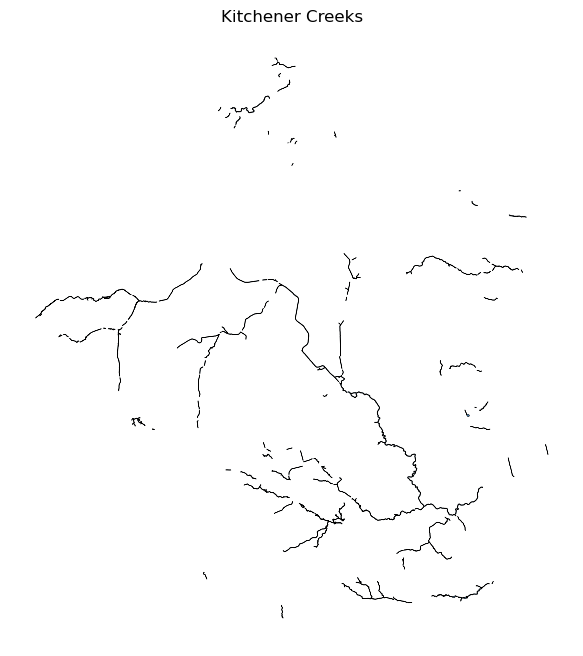

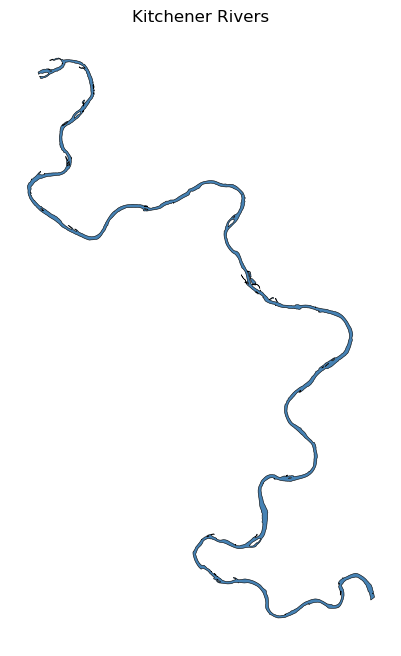

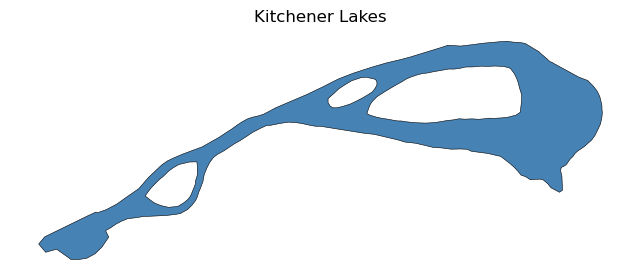

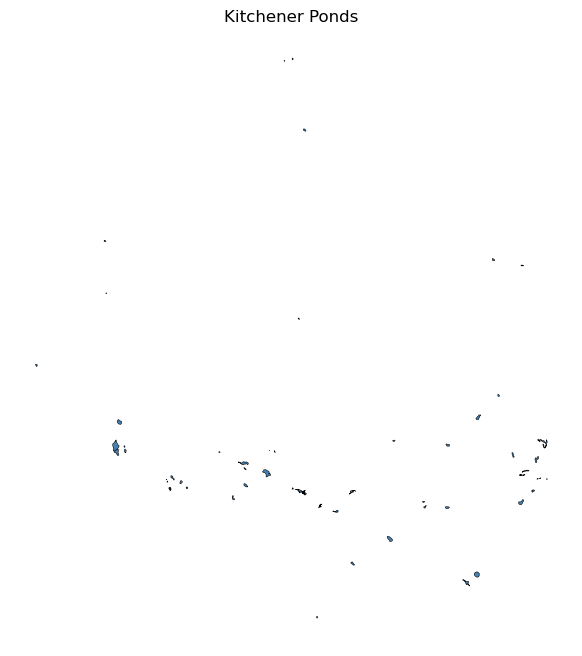

In [107]:
# ============================================================
# Kitchener Hydrography
# ============================================================

plot_dataset(
    kitchener_creeks,
    "Kitchener Creeks"
)

plot_dataset(
    kitchener_rivers,
    "Kitchener Rivers"
)

plot_dataset(
    kitchener_lakes,
    "Kitchener Lakes"
)

plot_dataset(
    kitchener_ponds,
    "Kitchener Ponds"
)

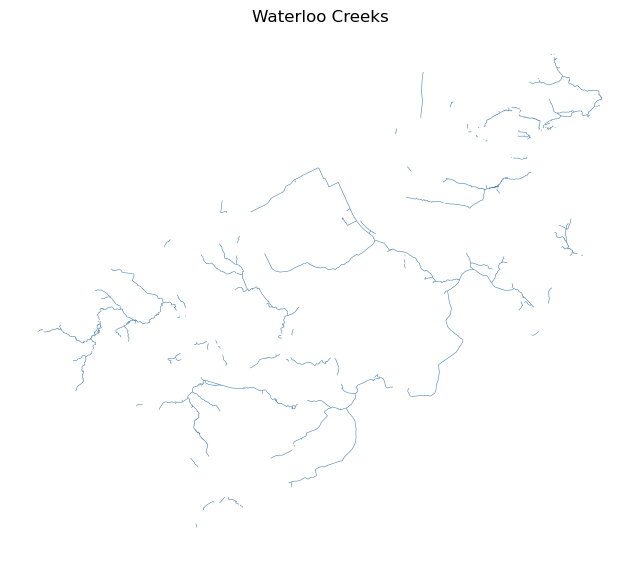

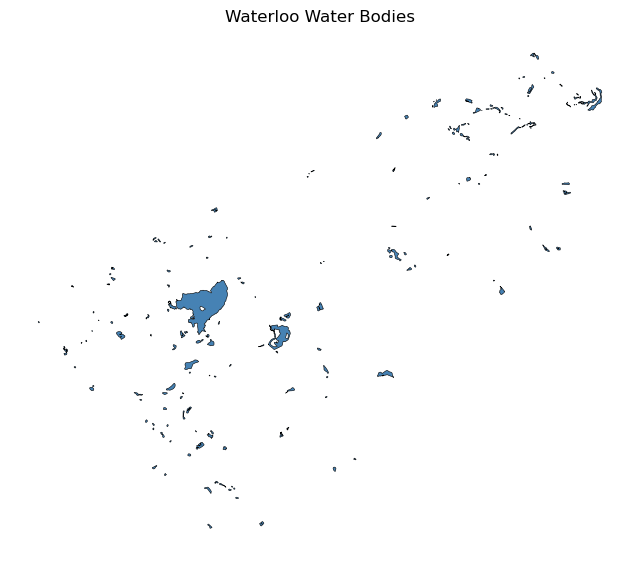

In [108]:
# ============================================================
# Waterloo Hydrography
# ============================================================

plot_dataset(
    waterloo_creeks,
    "Waterloo Creeks"
)

plot_dataset(
    waterloo_water,
    "Waterloo Water Bodies"
)

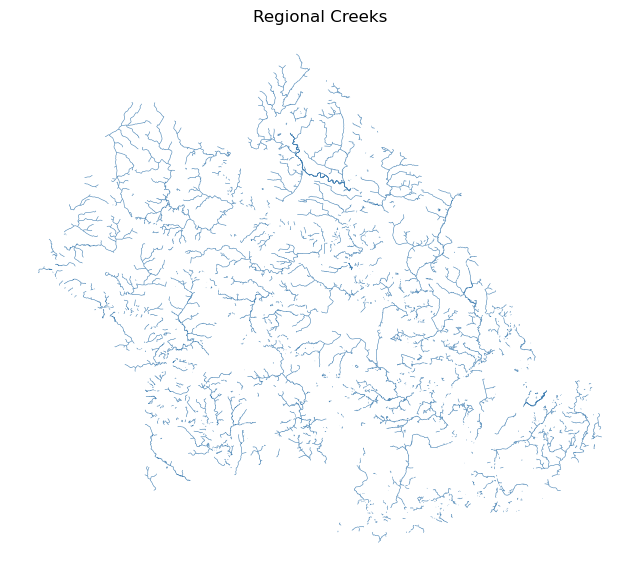

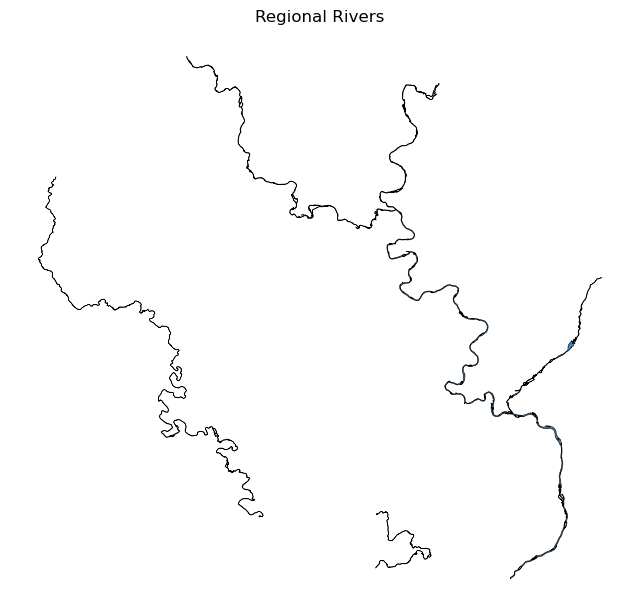

In [109]:
# ============================================================
# Regional Hydrography
# ============================================================

plot_dataset(
    regional_creeks,
    "Regional Creeks"
)

plot_dataset(
    regional_rivers,
    "Regional Rivers"
)

## 7. Coordinate Reference System Validation

Before hydrography datasets can be compared spatially, they must first be expressed within a common coordinate reference system (CRS). A CRS defines how locations on the Earth's surface are represented using geographic or projected coordinates.

If two datasets use different coordinate systems, features that represent the same river or lake may appear in different locations, preventing meaningful overlay analysis and producing incorrect measurements of distance, area, or overlap.

Because the hydrography datasets have already been standardized individually, this section simply verifies that they all use the same coordinate reference system before any inter-dataset comparisons are performed.

Although all datasets in this study originate from the Waterloo Region Geohub and are therefore expected to share the same CRS, performing this validation remains an important quality assurance step. Similar checks would be essential when integrating municipal, regional, provincial, or federal datasets collected from independent sources.

In [110]:
# ============================================================
# Coordinate Reference System Summary
# ============================================================

def crs_summary(name, gdf):

    return {

        "Dataset": name,
        "Features": len(gdf),
        "Geometry Types": ", ".join(sorted(gdf.geom_type.unique())),
        "CRS": gdf.crs.to_string()

    }


summary = pd.DataFrame([

    crs_summary("Waterloo Creeks", waterloo_creeks),
    crs_summary("Waterloo Water Bodies", waterloo_water),

    crs_summary("Kitchener Creeks", kitchener_creeks),
    crs_summary("Kitchener Rivers", kitchener_rivers),
    crs_summary("Kitchener Lakes", kitchener_lakes),
    crs_summary("Kitchener Ponds", kitchener_ponds),

    crs_summary("Regional Creeks", regional_creeks),
    crs_summary("Regional Rivers", regional_rivers)

])

display(summary)

,Dataset,Features,Geometry Types,CRS
0,Waterloo Creeks,318,"LineString, MultiLineString",EPSG:4326
1,Waterloo Water Bodies,187,"MultiPolygon, Polygon",EPSG:4326
2,Kitchener Creeks,70,"MultiPolygon, Polygon",EPSG:4326
3,Kitchener Rivers,1,MultiPolygon,EPSG:4326
4,Kitchener Lakes,1,Polygon,EPSG:4326
5,Kitchener Ponds,53,"MultiPolygon, Polygon",EPSG:4326
6,Regional Creeks,5457,"LineString, MultiLineString",EPSG:4326
7,Regional Rivers,85,"MultiPolygon, Polygon",EPSG:4326


In [111]:
# ============================================================
# Verify Coordinate Reference Systems
# ============================================================

crs_values = {

    "Waterloo Creeks": waterloo_creeks.crs,
    "Waterloo Water Bodies": waterloo_water.crs,

    "Kitchener Creeks": kitchener_creeks.crs,
    "Kitchener Rivers": kitchener_rivers.crs,
    "Kitchener Lakes": kitchener_lakes.crs,
    "Kitchener Ponds": kitchener_ponds.crs,

    "Regional Creeks": regional_creeks.crs,
    "Regional Rivers": regional_rivers.crs

}

reference = next(iter(crs_values.values()))

print("=" * 70)
print("Coordinate Reference System Validation")
print("=" * 70)

for dataset, crs in crs_values.items():

    status = "PASS" if crs == reference else "FAIL"

    print(f"{dataset:<30} {status}")

print()

if all(crs == reference for crs in crs_values.values()):

    print("All datasets use a common coordinate reference system.")
    print("The datasets are spatially compatible for comparison.")

else:

    print("One or more datasets use a different CRS.")
    print("These datasets should be reprojected before continuing.")

Coordinate Reference System Validation
Waterloo Creeks                PASS
Waterloo Water Bodies          PASS
Kitchener Creeks               PASS
Kitchener Rivers               PASS
Kitchener Lakes                PASS
Kitchener Ponds                PASS
Regional Creeks                PASS
Regional Rivers                PASS

All datasets use a common coordinate reference system.
The datasets are spatially compatible for comparison.


## 8. Dataset Metadata and Provenance

Spatial datasets are not only defined by their geometry and attributes, but also by their origin, publication history, and update frequency.

When combining hydrography datasets from multiple government sources, understanding where each dataset came from and when it was created or updated is important. Two datasets may describe the same water feature but differ because they were collected at different times, produced using different methods, or maintained by different organizations.

The metadata recorded in this section is obtained from the dataset information pages provided by each government source. These dates describe the dataset itself and are therefore retained as source metadata rather than feature attributes.

This distinction is important because the dates do not represent the date that an individual water feature was created or modified. For example, when the Kitchener hydrography dataset was separated into individual layers (creeks, rivers, lakes, and ponds), the original dataset metadata was preserved. The date associated with these new files represents the original Kitchener dataset, not the date that this notebook created the separated layers.

The following metadata fields are added:

| Field | Description |
|------|-------------|
| Source | Organization responsible for publishing the dataset |
| Government Level | Administrative level of the data provider |
| Country | Country of origin |
| Province | Province or territory |
| Region | Regional municipality |
| Municipality | Local municipality where applicable |
| Published Date | Original dataset publication date |
| Data Updated | Date the dataset contents were updated |
| Metadata Updated | Date the dataset information page was updated |

Separating these fields provides additional context when evaluating conflicting information during later merging steps. For example, if two datasets contain overlapping water features, the newer dataset may contain more current information. However, update date alone is not sufficient to determine which dataset should be preferred. Geometry quality, classification accuracy, feature completeness, and available attributes must also be considered.

Therefore, metadata is treated as one source of evidence during the merging process rather than an automatic rule for selecting one dataset over another.

### 8.1 Create Dataset Metadata Table

In [112]:
# ============================================================
# Dataset Metadata
# ============================================================

metadata = pd.DataFrame({

    "Dataset": [
        "Waterloo Creeks",
        "Waterloo Water Bodies",
        "Kitchener Creeks",
        "Kitchener Rivers",
        "Kitchener Lakes",
        "Kitchener Ponds",
        "Regional Creeks",
        "Regional Rivers"
    ],

    "Source": [
        "City of Waterloo",
        "City of Waterloo",
        "City of Kitchener",
        "City of Kitchener",
        "City of Kitchener",
        "City of Kitchener",
        "Region of Waterloo",
        "Region of Waterloo"
    ],

    "Government Level": [
        "Municipal",
        "Municipal",
        "Municipal",
        "Municipal",
        "Municipal",
        "Municipal",
        "Regional",
        "Regional"
    ],

    "Country": [
        "Canada",
        "Canada",
        "Canada",
        "Canada",
        "Canada",
        "Canada",
        "Canada",
        "Canada"
    ],

    "Province": [
        "Ontario",
        "Ontario",
        "Ontario",
        "Ontario",
        "Ontario",
        "Ontario",
        "Ontario",
        "Ontario"
    ],

    "Region": [
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region",
        "Waterloo Region"
    ],

    "Municipality": [
        "Waterloo",
        "Waterloo",
        "Kitchener",
        "Kitchener",
        "Kitchener",
        "Kitchener",
        None,
        None
    ],

    "Published Date": [
        "September 27, 2017",
        "September 27, 2017",
        "June 13, 2018",
        "June 13, 2018",
        "June 13, 2018",
        "June 13, 2018",
        "August 23, 2022",
        "August 23, 2022"
    ],

    "Data Updated": [
        "September 27, 2017",
        "September 27, 2017",
        "June 13, 2018",
        "June 13, 2018",
        "June 13, 2018",
        "June 13, 2018",
        "May 23, 2023",
        "May 23, 2023"
    ],

    "Metadata Updated": [
        "April 25, 2018",
        "April 25, 2018",
        "June 23, 2026",
        "June 23, 2026",
        "June 23, 2026",
        "June 23, 2026",
        "May 1, 2026",
        "May 1, 2026"
    ]

})


display(metadata)

,Dataset,Source,Government Level,Country,Province,Region,Municipality,Published Date,Data Updated,Metadata Updated
0,Waterloo Creeks,City of Waterloo,Municipal,Canada,Ontario,Waterloo Region,Waterloo,"September 27, 2017","September 27, 2017","April 25, 2018"
1,Waterloo Water Bodies,City of Waterloo,Municipal,Canada,Ontario,Waterloo Region,Waterloo,"September 27, 2017","September 27, 2017","April 25, 2018"
2,Kitchener Creeks,City of Kitchener,Municipal,Canada,Ontario,Waterloo Region,Kitchener,"June 13, 2018","June 13, 2018","June 23, 2026"
3,Kitchener Rivers,City of Kitchener,Municipal,Canada,Ontario,Waterloo Region,Kitchener,"June 13, 2018","June 13, 2018","June 23, 2026"
4,Kitchener Lakes,City of Kitchener,Municipal,Canada,Ontario,Waterloo Region,Kitchener,"June 13, 2018","June 13, 2018","June 23, 2026"
5,Kitchener Ponds,City of Kitchener,Municipal,Canada,Ontario,Waterloo Region,Kitchener,"June 13, 2018","June 13, 2018","June 23, 2026"
6,Regional Creeks,Region of Waterloo,Regional,Canada,Ontario,Waterloo Region,None,"August 23, 2022","May 23, 2023","May 1, 2026"
7,Regional Rivers,Region of Waterloo,Regional,Canada,Ontario,Waterloo Region,None,"August 23, 2022","May 23, 2023","May 1, 2026"


### 8.2 Metadata Observations

The metadata reveals important differences between the available datasets.

The Waterloo municipal hydrography layers are the oldest datasets currently available, with water features published in 2017 and metadata updated in 2018. Although these datasets remain valuable because they contain local information on water bodies that are absent from the regional datasets, their older collection date should be considered when comparing overlapping features.

The Kitchener hydrography dataset was published in 2018 but has recently updated metadata. The original dataset was separated into independent creek, river, lake, and pond layers during this workflow while retaining the original dataset dates.

The Region of Waterloo hydrography datasets are newer, with data updated in 2023. These datasets provide extensive coverage of regional rivers and creeks but do not include equivalent lake and pond datasets.

These differences demonstrate why hydrography integration cannot rely solely on dataset age. Older municipal datasets may contain unique information not available in newer regional datasets, while newer regional datasets may provide improved coverage or updated geometries. Later merging steps must therefore consider multiple indicators, including:

- geometry overlap,
- feature classification,
- feature names,
- spatial proximity,
- metadata reliability,
- attribute completeness.

Metadata provides valuable context, but final merging decisions require evaluation of the complete evidence available for each feature.

## 9. Visual Feature Comparison

### 9.1 Purpose for Visual Comparison

Before attempting any computational matching or merging, it is useful to visually compare the hydrography datasets that are expected to describe the same real-world features.

Although later sections will apply automated methods to identify duplicate or overlapping features, visual inspection remains an important part of geographic data integration. Human interpretation often identifies inconsistencies that are difficult to detect computationally, including slight positional offsets, segmentation differences, missing tributaries, or differences in mapping detail.

Unlike the original hydrography datasets, the standardized datasets created earlier contain only a single feature type. This allows comparisons to be performed between similar classes of hydrographic features rather than comparing unrelated water features.

For example:

- Kitchener Creeks are compared with Regional Creeks.
- Kitchener Rivers are compared with Regional Rivers.
- Waterloo Creeks are compared with Regional Creeks.

Comparing similar feature types reduces ambiguity and increases confidence when identifying potential duplicate features.

The objective of this section is **not** to merge datasets. Instead, it provides visual evidence that will guide the automated matching procedures developed in the following sections.

In [113]:
from matplotlib.lines import Line2D

# ============================================================
# Overlay Comparison Helper
# ============================================================

def compare_datasets(
    local,
    regional,
    local_name,
    regional_name,
    figsize=(8, 8)
):

    fig, ax = plt.subplots(figsize=figsize)

    # Plot the larger regional dataset first so that the
    # municipal dataset remains visible above it.
    regional.plot(
        ax=ax,
        color="steelblue",
        edgecolor="steelblue",
        linewidth=0.5,
        alpha=0.35
    )

    local.plot(
        ax=ax,
        color="red",
        edgecolor="darkred",
        linewidth=1.4,
        alpha=0.9
    )

    legend_elements = [
        Line2D(
            [0],
            [0],
            color="steelblue",
            lw=3,
            label=regional_name
        ),
        Line2D(
            [0],
            [0],
            color="red",
            lw=3,
            label=local_name
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="best"
    )

    ax.set_title(
        f"{local_name} vs {regional_name}"
    )

    ax.set_axis_off()

    plt.show()

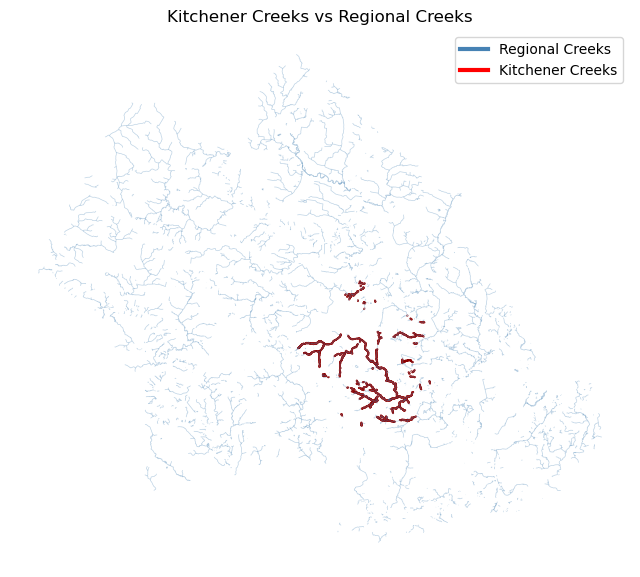

In [114]:
# ============================================================
# Kitchener Creeks vs Regional Creeks
# ============================================================

compare_datasets(

    kitchener_creeks,

    regional_creeks,

    "Kitchener Creeks",

    "Regional Creeks"

)

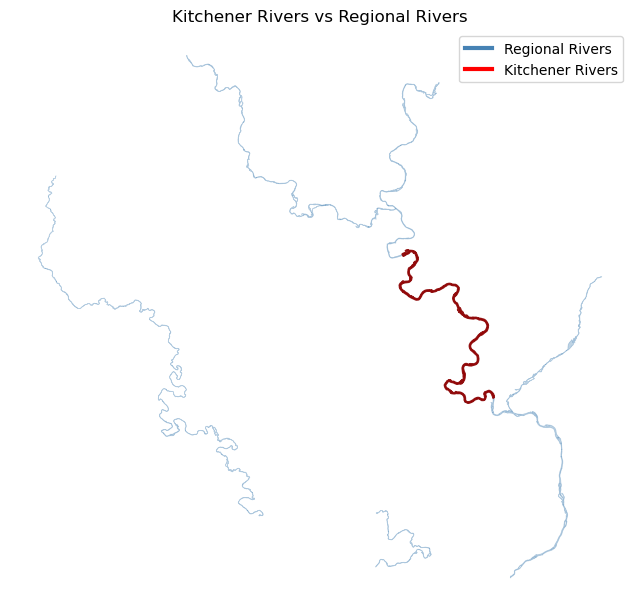

In [115]:
# ============================================================
# Kitchener Rivers vs Regional Rivers
# ============================================================

compare_datasets(

    kitchener_rivers,

    regional_rivers,

    "Kitchener Rivers",

    "Regional Rivers"

)

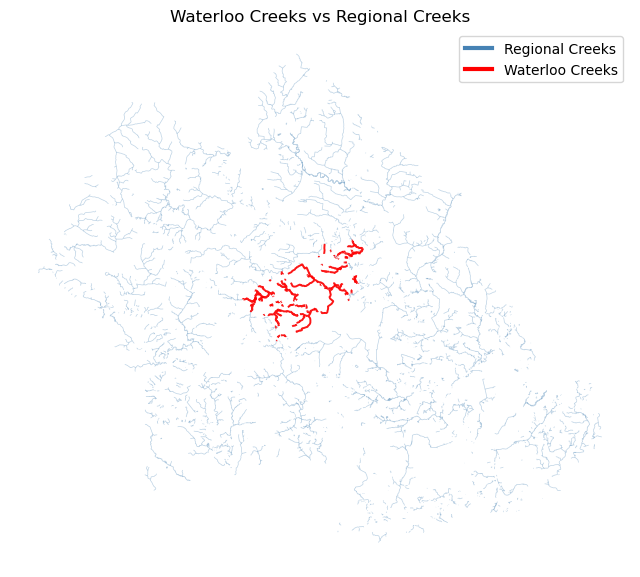

In [116]:
# ============================================================
# Waterloo Creeks vs Regional Creeks
# ============================================================

compare_datasets(

    waterloo_creeks,

    regional_creeks,

    "Waterloo Creeks",

    "Regional Creeks"

)

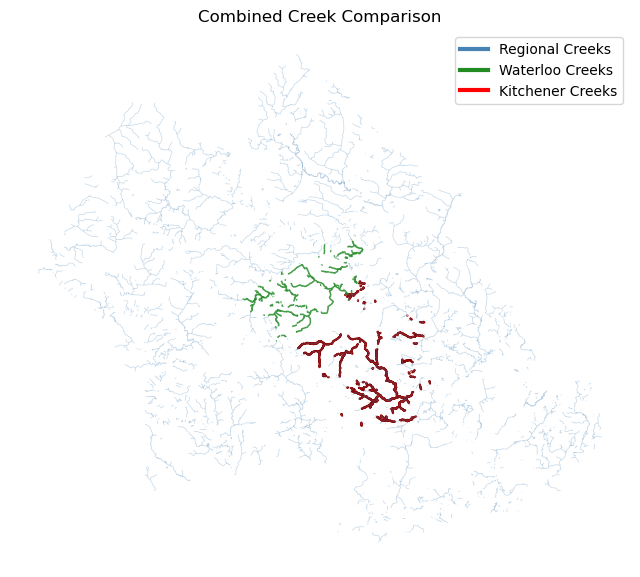

In [117]:
# ============================================================
# Combined Creek Comparison
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the dense regional dataset first.
regional_creeks.plot(
    ax=ax,
    color="steelblue",
    edgecolor="steelblue",
    linewidth=0.5,
    alpha=0.30
)

# Plot Waterloo above the regional layer.
waterloo_creeks.plot(
    ax=ax,
    color="forestgreen",
    edgecolor="darkgreen",
    linewidth=1.1,
    alpha=0.8
)

# Plot Kitchener last so its smaller, localized network
# remains as visible as possible.
kitchener_creeks.plot(
    ax=ax,
    color="red",
    edgecolor="darkred",
    linewidth=1.5,
    alpha=0.95
)

legend_elements = [
    Line2D(
        [0],
        [0],
        color="steelblue",
        lw=3,
        label="Regional Creeks"
    ),
    Line2D(
        [0],
        [0],
        color="forestgreen",
        lw=3,
        label="Waterloo Creeks"
    ),
    Line2D(
        [0],
        [0],
        color="red",
        lw=3,
        label="Kitchener Creeks"
    )
]

ax.legend(
    handles=legend_elements,
    loc="best"
)

ax.set_title(
    "Combined Creek Comparison"
)

ax.set_axis_off()

plt.show()

### 9.2 Summary

Visual inspection indicates that the municipal river and creek datasets correspond closely with the features represented in the regional datasets. The municipal geometries generally follow the same watercourses as their regional equivalents, although differences in segmentation, positional accuracy, geometric detail, and geographic extent remain visible.

The strong visual correspondence suggests that the Region of Waterloo's rivers and creeks may already contain most of the information represented in the City of Kitchener and City of Waterloo watercourse datasets. It may therefore be possible to use the regional rivers and creeks as the primary watercourse layers while excluding municipal records that do not contribute additional geometry or metadata.

However, visual similarity alone is not sufficient evidence for discarding the municipal datasets. Municipal layers may contain unique segments, more detailed geometries, additional attributes, or different naming conventions that are not immediately apparent through visual inspection alone. Consequently, the analysis continues rather than assuming that the regional datasets are automatically complete.

Before features can be compared across different data sources, another important issue must first be addressed. A single real-world creek or river is often represented as multiple separate records within the same dataset. These records may correspond to adjacent segments of the same named watercourse rather than distinct hydrographic features.

The next section addresses this internal segmentation problem by developing conservative rules for consolidating records that can be identified with high confidence as belonging to the same hydrographic feature. Resolving segmentation within each dataset provides a more reliable foundation for the cross-dataset matching and merging procedures that follow.


## 10. Internal Feature Consolidation

### 10.1 Introduction

Before hydrography datasets from different organizations can be compared, it is important to ensure that each dataset is internally consistent.

Many government hydrography datasets represent a single real-world creek or river as multiple individual records rather than one continuous feature. This process, known as **segmentation**, is common in GIS databases. Segments may be created because different portions of a watercourse were mapped separately, because administrative boundaries divide a river into multiple records, or because different sections possess different physical characteristics or associated attributes.

Segmentation is not inherently incorrect. In fact, it is often desirable for detailed management of geographic data. However, it complicates later comparison and merging because two datasets may represent the same river using very different segmentation schemes. One dataset may store an entire river as a single feature, while another may divide the same river into dozens of individual segments.

Before comparing datasets from different organizations, this notebook first attempts to consolidate segmented features **within each dataset**. Performing this step first reduces unnecessary duplication and simplifies later feature matching.

Several approaches could be used to identify segments belonging to the same hydrographic feature.

1. **Feature Names** — segments sharing the same name can often be consolidated with high confidence.
2. **Geometric Relationships** — touching or overlapping geometries may indicate connected segments, although geometric proximity alone does not guarantee that two features represent the same watercourse.
3. **Manual Review** — visual inspection using the original government datasets provides the highest confidence but requires considerably more effort.

Whenever possible, this notebook relies on feature names because they provide the strongest semantic evidence that two records describe the same real-world feature.

Before applying any consolidation rules, however, the reliability of the name fields must first be evaluated.

### 10.2 Name Completeness Audit

In [118]:
# ============================================================
# Name Completeness Audit
# ============================================================

def audit_name_field(dataset_name, gdf):

    if "Name" not in gdf.columns:

        return {
            "Dataset": dataset_name,
            "Features": len(gdf),
            "Named Features": None,
            "Unnamed Features": None,
            "Completeness (%)": None,
            "Status": "Name field missing",
            "Available Fields": ", ".join(gdf.columns)
        }

    names = gdf["Name"]

    normalized_names = (
        names
        .astype("string")
        .str.strip()
    )

    missing_mask = (
        names.isna()
        | normalized_names.eq("")
        | normalized_names.str.lower().isin(
            [
                "none",
                "null",
                "nan",
                "unknown",
                "unnamed"
            ]
        )
    )

    total = len(gdf)
    unnamed = int(missing_mask.sum())
    named = total - unnamed

    completeness = (
        round((named / total) * 100, 1)
        if total > 0
        else 0.0
    )

    if completeness >= 90:

        status = "High name completeness"

    elif completeness >= 60:

        status = "Moderate name completeness"

    else:

        status = "Low name completeness"

    return {
        "Dataset": dataset_name,
        "Features": total,
        "Named Features": named,
        "Unnamed Features": unnamed,
        "Completeness (%)": completeness,
        "Status": status,
        "Available Fields": None
    }


name_audit = pd.DataFrame(
    [
        audit_name_field(
            "Waterloo Creeks",
            waterloo_creeks
        ),
        audit_name_field(
            "Kitchener Creeks",
            kitchener_creeks
        ),
        audit_name_field(
            "Kitchener Rivers",
            kitchener_rivers
        ),
        audit_name_field(
            "Regional Creeks",
            regional_creeks
        ),
        audit_name_field(
            "Regional Rivers",
            regional_rivers
        )
    ]
)

display(name_audit)

,Dataset,Features,Named Features,Unnamed Features,Completeness (%),Status,Available Fields
0,Waterloo Creeks,318,217,101,68.2,Moderate name completeness,None
1,Kitchener Creeks,70,70,0,100.0,High name completeness,None
2,Kitchener Rivers,1,1,0,100.0,High name completeness,None
3,Regional Creeks,5457,1127,4330,20.7,Low name completeness,None
4,Regional Rivers,85,85,0,100.0,High name completeness,None


### 10.3 Name Audit Results and Consolidation Strategy

The name completeness audit reveals substantial differences in attribute quality between the municipal and regional datasets.

| Dataset | Named Features | Unnamed Features | Name Completeness |
|---|---:|---:|---:|
| Waterloo Creeks | 217 | 101 | 68.2% |
| Kitchener Creeks | 70 | 0 | 100.0% |
| Kitchener Rivers | 1 | 0 | 100.0% |
| Regional Creeks | 1,127 | 4,330 | 20.7% |
| Regional Rivers | 85 | 0 | 100.0% |

These results demonstrate that feature names cannot be treated as equally reliable across all datasets.

The Kitchener watercourse data have complete name coverage. The Kitchener Rivers layer contains only one named record representing the Grand River, so no internal consolidation is required. The Kitchener Creeks layer is also fully named, making it well suited to name-based consolidation.

The Regional Rivers dataset contains 85 named records. These records appear to represent segmented portions of a much smaller number of real-world rivers, primarily the Grand River and Nith River. Because every segment has a name, the regional river data provide a straightforward first case for internal consolidation.

The creek datasets are more difficult. Approximately one-third of the Waterloo municipal creek records are unnamed, while nearly four-fifths of the Regional Creeks records have no name. This limits the ability to consolidate these datasets using names alone.

The comparison also reveals an important advantage of the municipal datasets. Although the regional creek layer contains much broader geographic coverage, the municipal layers provide substantially better naming information within their jurisdictions. The municipal datasets should therefore not be discarded merely because their geometries overlap the regional data. Their attributes may be useful for identifying, naming, and enriching regional features later in the integration process.

Based on these findings, consolidation will proceed in stages:

1. Skip datasets that are already represented by a single record, such as Kitchener Rivers.
2. Consolidate datasets with complete name coverage, beginning with Regional Rivers.
3. Consolidate named creek records while preserving unnamed records as independent features.
4. Flag uncertain or unnamed connections for later geometric analysis or manual review.
5. Avoid assigning unnamed features to named watercourses without sufficient evidence.

The following conservative rules will guide consolidation:

| Rule | Action |
|---|---|
| Same normalized feature name | Consolidate automatically |
| Different feature names | Never consolidate |
| Missing feature name | Preserve as an independent record |
| Same name but disconnected geometry | Preserve within one multipart feature |
| Ambiguous relationship | Flag for manual review |
| Uncertain result | Preserve the original records |

A shared name provides strong evidence of shared feature identity, even when the stored geometries do not physically touch. In these situations, the geometries may be retained as parts of a `MultiPolygon` or `MultiLineString` rather than forcing artificial geometric connections.

Hydrological connectivity alone is not sufficient evidence of feature identity. An unnamed tributary, pond, or side channel may touch a named creek without being part of the same mapped feature. Consequently, unnamed geometries will not be attached automatically to named watercourses.

The central rule of this workflow is:

> **When uncertainty exists, preserve information rather than infer it.**

### 10.4 Consolidate Regional River Segments

The Regional Rivers dataset provides the simplest case for internal feature consolidation.

The dataset contains 85 records, and every record has a populated feature name. These records appear to represent separate mapped segments of a much smaller number of real-world rivers. Because name completeness is 100%, segments sharing the same normalized name can be consolidated with high confidence.

Before consolidation, feature names are normalized to prevent superficial formatting differences from creating separate groups. Normalization removes unnecessary surrounding spaces, reduces repeated spaces, and converts names to consistent title casing.

For example, the following values would be treated as equivalent:

$$
\text{GRAND RIVER}
=
\text{Grand River}
=
\text{ grand river }
$$

All segments sharing the same normalized name are dissolved into one feature. The resulting geometry may be a single polygon or a multipart geometry depending on whether every segment is spatially connected.

The original regional river data remain unchanged. Consolidation produces a new working dataset named `regional_rivers_consolidated`.

In [120]:
# ============================================================
# Inspect Regional River Segmentation by Name
# ============================================================

regional_river_name_counts = (
    regional_rivers["Name"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.title()
    .value_counts()
    .rename_axis("Name")
    .reset_index(name="Segment Count")
)

display(regional_river_name_counts)

,Name,Segment Count
0,Nith River,38
1,Grand River,21
2,Conestogo River,15
3,Speed River,11


In [121]:
# ============================================================
# Consolidate Regional River Segments
# ============================================================

regional_rivers_working = regional_rivers.copy()

# ------------------------------------------------------------
# Normalize river names
# ------------------------------------------------------------

regional_rivers_working["Normalized Name"] = (
    regional_rivers_working["Name"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.title()
)

# ------------------------------------------------------------
# Preserve the number of original segments in each group
# ------------------------------------------------------------

segment_counts = (
    regional_rivers_working
    .groupby("Normalized Name")
    .size()
    .rename("Original Segment Count")
)

# ------------------------------------------------------------
# Dissolve all segments sharing the same normalized name
# ------------------------------------------------------------

regional_rivers_consolidated = (
    regional_rivers_working
    .dissolve(
        by="Normalized Name",
        aggfunc="first",
        as_index=False
    )
)

# ------------------------------------------------------------
# Restore the standardized name and classification fields
# ------------------------------------------------------------

regional_rivers_consolidated["Name"] = (
    regional_rivers_consolidated["Normalized Name"]
)

regional_rivers_consolidated["Feature Class"] = (
    "Water Course"
)

regional_rivers_consolidated["Feature Type"] = (
    "River"
)

regional_rivers_consolidated["Feature Subtype"] = None

# ------------------------------------------------------------
# Add original segment counts
# ------------------------------------------------------------

regional_rivers_consolidated[
    "Original Segment Count"
] = (
    regional_rivers_consolidated["Normalized Name"]
    .map(segment_counts)
)

# ------------------------------------------------------------
# Repair any geometry created by the dissolve operation
# ------------------------------------------------------------

regional_rivers_consolidated.geometry = (
    regional_rivers_consolidated.geometry.make_valid()
)

regional_rivers_consolidated = (
    regional_rivers_consolidated.reset_index(drop=True)
)

In [122]:
# ============================================================
# Regional River Consolidation Results
# ============================================================

original_feature_count = len(
    regional_rivers
)

consolidated_feature_count = len(
    regional_rivers_consolidated
)

records_removed = (
    original_feature_count
    - consolidated_feature_count
)

invalid_after_consolidation = (
    ~regional_rivers_consolidated.geometry.is_valid
).sum()

print("=" * 70)
print("Regional River Consolidation")
print("=" * 70)

print(
    f"Original river records       : "
    f"{original_feature_count}"
)

print(
    f"Consolidated river features  : "
    f"{consolidated_feature_count}"
)

print(
    f"Segment records consolidated : "
    f"{records_removed}"
)

print(
    f"Invalid output geometries    : "
    f"{invalid_after_consolidation}"
)

print()

if invalid_after_consolidation == 0:

    print(
        "All consolidated river geometries are valid."
    )

else:

    print(
        "One or more consolidated geometries require review."
    )

Regional River Consolidation
Original river records       : 85
Consolidated river features  : 4
Segment records consolidated : 81
Invalid output geometries    : 0

All consolidated river geometries are valid.


In [123]:
# ============================================================
# Consolidated Regional River Summary
# ============================================================

regional_river_summary = (
    regional_rivers_consolidated[
        [
            "Name",
            "Feature Class",
            "Feature Type",
            "Original Segment Count",
            "geometry"
        ]
    ]
    .copy()
)

regional_river_summary[
    "Geometry Type"
] = (
    regional_river_summary.geometry.geom_type
)

display(
    regional_river_summary.drop(
        columns="geometry"
    )
)

,Name,Feature Class,Feature Type,Original Segment Count,Geometry Type
0,Conestogo River,Water Course,River,15,MultiPolygon
1,Grand River,Water Course,River,21,MultiPolygon
2,Nith River,Water Course,River,38,MultiPolygon
3,Speed River,Water Course,River,11,MultiPolygon


### 10.5 Consolidate Kitchener Creek Segments

The Kitchener Creeks dataset is also well suited to name-based consolidation because every record contains a populated feature name.

Unlike the Regional Rivers dataset, however, the Kitchener creek layer contains many more distinct named features. Some creeks may be represented by a single geometry, while others may be divided into several segments.

The same conservative consolidation method is applied:

1. Normalize creek names.
2. Count how many records share each name.
3. Dissolve records with the same normalized name.
4. Preserve disconnected pieces as multipart geometries.
5. Validate the resulting geometries.
6. Report how many segmented records were consolidated.

Because name completeness is 100%, this operation can be performed with high confidence. No unnamed geometries require separate treatment at this stage.

In [125]:
# ============================================================
# Inspect Kitchener Creek Segmentation by Name
# ============================================================

kitchener_creek_name_counts = (
    kitchener_creeks["Name"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.title()
    .value_counts()
    .rename_axis("Name")
    .reset_index(name="Segment Count")
)

display(
    kitchener_creek_name_counts
)

,Name,Segment Count
0,Grand River Tributary,14
1,Strasburg Creek Tributary,10
2,Unnamed Tributary,6
3,Laurel Creek Tributary,4
4,Montgomery Creek Tributary,3
5,Schneider Creek Tributary,3
6,Blair Creek Tributary,3
7,Laurentian Wetlands Tributary,2
8,Storm Facility Tributary,2
9,School Creek,1


In [128]:
# ============================================================
# Consolidate Kitchener Creek Segments
# ============================================================

kitchener_creeks_working = (
    kitchener_creeks.copy()
)

# ------------------------------------------------------------
# Normalize creek names
# ------------------------------------------------------------

kitchener_creeks_working[
    "Normalized Name"
] = (
    kitchener_creeks_working["Name"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.title()
)

# ------------------------------------------------------------
# Count original segments for each creek
# ------------------------------------------------------------

segment_counts = (
    kitchener_creeks_working
    .groupby("Normalized Name")
    .size()
    .rename("Original Segment Count")
)

# ------------------------------------------------------------
# Dissolve segments sharing the same creek name
# ------------------------------------------------------------

kitchener_creeks_consolidated = (
    kitchener_creeks_working
    .dissolve(
        by="Normalized Name",
        aggfunc="first",
        as_index=False
    )
)

# ------------------------------------------------------------
# Restore standardized attributes
# ------------------------------------------------------------

kitchener_creeks_consolidated["Name"] = (
    kitchener_creeks_consolidated[
        "Normalized Name"
    ]
)

kitchener_creeks_consolidated[
    "Feature Class"
] = "Water Course"

kitchener_creeks_consolidated[
    "Feature Type"
] = "Creek"

kitchener_creeks_consolidated[
    "Feature Subtype"
] = None

# ------------------------------------------------------------
# Preserve original segment counts
# ------------------------------------------------------------

kitchener_creeks_consolidated[
    "Original Segment Count"
] = (
    kitchener_creeks_consolidated[
        "Normalized Name"
    ]
    .map(segment_counts)
)

# ------------------------------------------------------------
# Validate output geometry
# ------------------------------------------------------------

kitchener_creeks_consolidated.geometry = (
    kitchener_creeks_consolidated
    .geometry
    .make_valid()
)

kitchener_creeks_consolidated = (
    kitchener_creeks_consolidated
    .reset_index(drop=True)
)

In [129]:
# ============================================================
# Kitchener Creek Consolidation Results
# ============================================================

original_feature_count = len(
    kitchener_creeks
)

consolidated_feature_count = len(
    kitchener_creeks_consolidated
)

records_consolidated = (
    original_feature_count
    - consolidated_feature_count
)

invalid_after_consolidation = (
    ~kitchener_creeks_consolidated
    .geometry
    .is_valid
).sum()

print("=" * 70)
print("Kitchener Creek Consolidation")
print("=" * 70)

print(
    f"Original creek records       : "
    f"{original_feature_count}"
)

print(
    f"Consolidated creek features  : "
    f"{consolidated_feature_count}"
)

print(
    f"Segment records consolidated : "
    f"{records_consolidated}"
)

print(
    f"Invalid output geometries    : "
    f"{invalid_after_consolidation}"
)

print()

if invalid_after_consolidation == 0:

    print(
        "All consolidated creek geometries are valid."
    )

else:

    print(
        "One or more consolidated geometries "
        "require review."
    )

Kitchener Creek Consolidation
Original creek records       : 70
Consolidated creek features  : 32
Segment records consolidated : 38
Invalid output geometries    : 0

All consolidated creek geometries are valid.


In [130]:
# ============================================================
# Kitchener Creek Consolidation Summary
# ============================================================

kitchener_creek_summary = (
    kitchener_creeks_consolidated[
        [
            "Name",
            "Feature Class",
            "Feature Type",
            "Original Segment Count",
            "geometry"
        ]
    ]
    .copy()
)

kitchener_creek_summary[
    "Geometry Type"
] = (
    kitchener_creek_summary
    .geometry
    .geom_type
)

display(
    kitchener_creek_summary
    .drop(columns="geometry")
    .sort_values(
        by="Original Segment Count",
        ascending=False
    )
    .reset_index(drop=True)
)

,Name,Feature Class,Feature Type,Original Segment Count,Geometry Type
0,Grand River Tributary,Water Course,Creek,14,MultiPolygon
1,Strasburg Creek Tributary,Water Course,Creek,10,MultiPolygon
2,Unnamed Tributary,Water Course,Creek,6,MultiPolygon
3,Laurel Creek Tributary,Water Course,Creek,4,MultiPolygon
4,Schneider Creek Tributary,Water Course,Creek,3,MultiPolygon
5,Blair Creek Tributary,Water Course,Creek,3,MultiPolygon
6,Montgomery Creek Tributary,Water Course,Creek,3,MultiPolygon
7,Storm Facility Tributary,Water Course,Creek,2,MultiPolygon
8,Laurentian Wetlands Tributary,Water Course,Creek,2,MultiPolygon
9,Balzer Creek Tributary,Water Course,Creek,1,Polygon


### 10.6 Consolidate Waterloo Municipal Creek Segments

The Waterloo Creeks dataset requires a more conservative consolidation method than the previous datasets.

Of its 318 records:

- 217 contain a feature name,
- 101 are unnamed,
- name completeness is approximately 68.2%.

Named records can be consolidated using the same high-confidence rule applied to the Regional Rivers and Kitchener Creeks datasets. Records sharing the same normalized name are interpreted as segments of the same mapped creek and may therefore be dissolved into a single multipart feature.

Unnamed records cannot be consolidated in the same manner because they contain no semantic identifier linking them to a specific creek.

Some unnamed records may represent:

- unnamed tributaries,
- separate drainage channels,
- disconnected portions of a named creek,
- small segments whose names were omitted,
- features that should remain independent.

Spatial contact with a named creek is not sufficient evidence for automatic consolidation. A tributary may touch a named creek while remaining a distinct hydrographic feature. Similarly, a drainage channel or side branch may intersect a creek without sharing its identity.

The Waterloo creek consolidation therefore follows two separate paths:

1. **Named records** are consolidated automatically by normalized feature name.
2. **Unnamed records** remain unchanged and are assigned a review status.

After consolidation, the named and unnamed records are visualized separately. Unnamed features that intersect or touch consolidated named creeks are identified as candidate records for manual review, but they are not merged automatically.

This preserves all available information while allowing uncertain relationships to be investigated without introducing unsupported assumptions.

#### 10.6.1 Separate Named and Unnamed Records

In [132]:
# ============================================================
# Separate Named and Unnamed Waterloo Creek Records
# ============================================================

waterloo_creeks_working = waterloo_creeks.copy()

waterloo_creeks_working["Normalized Name"] = (
    waterloo_creeks_working["Name"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.title()
)

unnamed_mask = (
    waterloo_creeks_working["Name"].isna()
    | waterloo_creeks_working["Normalized Name"].eq("")
    | waterloo_creeks_working["Normalized Name"]
        .str.lower()
        .isin(
            [
                "none",
                "null",
                "nan",
                "unknown",
                "unnamed"
            ]
        )
)

waterloo_creeks_named = (
    waterloo_creeks_working.loc[
        ~unnamed_mask
    ]
    .copy()
)

waterloo_creeks_unnamed = (
    waterloo_creeks_working.loc[
        unnamed_mask
    ]
    .copy()
)

print("=" * 70)
print("Waterloo Creek Name Separation")
print("=" * 70)

print(
    f"Total creek records   : "
    f"{len(waterloo_creeks_working)}"
)

print(
    f"Named creek records   : "
    f"{len(waterloo_creeks_named)}"
)

print(
    f"Unnamed creek records : "
    f"{len(waterloo_creeks_unnamed)}"
)

Waterloo Creek Name Separation
Total creek records   : 318
Named creek records   : 217
Unnamed creek records : 101


#### 10.6.2 Inspect Named Segmentation

In [133]:
# ============================================================
# Inspect Waterloo Named Creek Segmentation
# ============================================================

waterloo_creek_name_counts = (
    waterloo_creeks_named["Normalized Name"]
    .value_counts()
    .rename_axis("Name")
    .reset_index(name="Segment Count")
)

display(
    waterloo_creek_name_counts
    .sort_values(
        by="Segment Count",
        ascending=False
    )
    .reset_index(drop=True)
)

,Name,Segment Count
0,Laurel Creek,94
1,Clair Creek,37
2,Forwell Creek,20
3,Colonial Creek,16
4,Melitzer Creek,12
5,Creek C,10
6,Critter Creek,6
7,Monastery Creek,5
8,Maple Hill,3
9,Cedar Creek,3


#### 10.6.3 Consolidate Named Creek Segments

In [135]:
# ============================================================
# Consolidate Named Waterloo Creek Segments
# ============================================================

waterloo_named_segment_counts = (
    waterloo_creeks_named
    .groupby("Normalized Name")
    .size()
    .rename("Original Segment Count")
)

waterloo_creeks_named_consolidated = (
    waterloo_creeks_named
    .dissolve(
        by="Normalized Name",
        aggfunc="first",
        as_index=False
    )
)

waterloo_creeks_named_consolidated["Name"] = (
    waterloo_creeks_named_consolidated[
        "Normalized Name"
    ]
)

waterloo_creeks_named_consolidated[
    "Feature Class"
] = "Water Course"

waterloo_creeks_named_consolidated[
    "Feature Type"
] = "Creek"

waterloo_creeks_named_consolidated[
    "Original Segment Count"
] = (
    waterloo_creeks_named_consolidated[
        "Normalized Name"
    ]
    .map(waterloo_named_segment_counts)
)

waterloo_creeks_named_consolidated.geometry = (
    waterloo_creeks_named_consolidated
    .geometry
    .make_valid()
)

waterloo_creeks_named_consolidated = (
    waterloo_creeks_named_consolidated
    .reset_index(drop=True)
)

#### 10.6.4 Preserve Unnamed Records

In [136]:
# ============================================================
# Prepare Unnamed Waterloo Creek Records
# ============================================================

waterloo_creeks_unnamed = (
    waterloo_creeks_unnamed
    .reset_index(drop=True)
)

waterloo_creeks_unnamed[
    "Original Segment Count"
] = 1

waterloo_creeks_unnamed[
    "Review Status"
] = "Unreviewed unnamed feature"

waterloo_creeks_unnamed[
    "Candidate Named Creek"
] = None

#### 10.6.5 Report Consolidation Results

In [138]:
# ============================================================
# Waterloo Creek Consolidation Results
# ============================================================

original_feature_count = len(
    waterloo_creeks
)

original_named_count = len(
    waterloo_creeks_named
)

consolidated_named_count = len(
    waterloo_creeks_named_consolidated
)

named_records_consolidated = (
    original_named_count
    - consolidated_named_count
)

unnamed_feature_count = len(
    waterloo_creeks_unnamed
)

invalid_named_outputs = (
    ~waterloo_creeks_named_consolidated
    .geometry
    .is_valid
).sum()

invalid_unnamed_outputs = (
    ~waterloo_creeks_unnamed
    .geometry
    .is_valid
).sum()

print("=" * 70)
print("Waterloo Creek Consolidation")
print("=" * 70)

print(
    f"Original creek records          : "
    f"{original_feature_count}"
)

print(
    f"Original named records          : "
    f"{original_named_count}"
)

print(
    f"Consolidated named features     : "
    f"{consolidated_named_count}"
)

print(
    f"Named segment records combined  : "
    f"{named_records_consolidated}"
)

print(
    f"Unnamed records preserved       : "
    f"{unnamed_feature_count}"
)

print(
    f"Invalid named outputs           : "
    f"{invalid_named_outputs}"
)

print(
    f"Invalid unnamed outputs         : "
    f"{invalid_unnamed_outputs}"
)

Waterloo Creek Consolidation
Original creek records          : 318
Original named records          : 217
Consolidated named features     : 17
Named segment records combined  : 200
Unnamed records preserved       : 101
Invalid named outputs           : 0
Invalid unnamed outputs         : 0


#### 10.6.6 Identify Review Candidates

This uses geometric intersection only to flag records. It does not merge anything.

In [139]:
# ============================================================
# Identify Unnamed Features Intersecting Named Creeks
# ============================================================

named_creek_union = (
    waterloo_creeks_named_consolidated
    .geometry
    .union_all()
)

intersects_named = (
    waterloo_creeks_unnamed
    .geometry
    .intersects(named_creek_union)
)

waterloo_creeks_unnamed.loc[
    intersects_named,
    "Review Status"
] = "Intersects named creek — review required"

waterloo_creeks_unnamed.loc[
    ~intersects_named,
    "Review Status"
] = "No intersection with named creek"

review_summary = (
    waterloo_creeks_unnamed[
        "Review Status"
    ]
    .value_counts()
    .rename_axis("Review Status")
    .reset_index(name="Feature Count")
)

display(review_summary)

,Review Status,Feature Count
0,No intersection with named creek,69
1,Intersects named creek — review required,32


#### 10.6.7 Find Candidate Named Creeks

An unnamed record may intersect more than one named creek, so these remain candidates rather than confirmed matches.

In [140]:
# ============================================================
# Find Candidate Named Creek Matches
# ============================================================

review_candidates = (
    waterloo_creeks_unnamed.loc[
        waterloo_creeks_unnamed[
            "Review Status"
        ] == "Intersects named creek — review required"
    ]
    .copy()
)

candidate_records = []

for unnamed_index, unnamed_row in review_candidates.iterrows():

    matches = (
        waterloo_creeks_named_consolidated[
            waterloo_creeks_named_consolidated
            .geometry
            .intersects(
                unnamed_row.geometry
            )
        ]
    )

    candidate_names = (
        matches["Name"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    candidate_records.append(
        {
            "Unnamed Index": unnamed_index,
            "Original OBJECTID": unnamed_row.get(
                "OBJECTID",
                None
            ),
            "Candidate Named Creeks": (
                ", ".join(candidate_names)
                if candidate_names
                else None
            ),
            "Candidate Count": len(candidate_names)
        }
    )

waterloo_manual_review = pd.DataFrame(
    candidate_records
)

display(waterloo_manual_review)

,Unnamed Index,Original OBJECTID,Candidate Named Creeks,Candidate Count
0,0,1,Clair Creek,1
1,7,34,Laurel Creek,1
2,9,44,Colonial Creek,1
3,11,53,Laurel Creek,1
4,14,58,Creek C,1
5,16,67,Creek C,1
6,21,81,Creek C,1
7,22,91,Colonial Creek,1
8,23,92,Horst Creek,1
9,24,93,Cedar Creek,1


#### 10.6.8 Visualize Consolidated and Unnamed Features

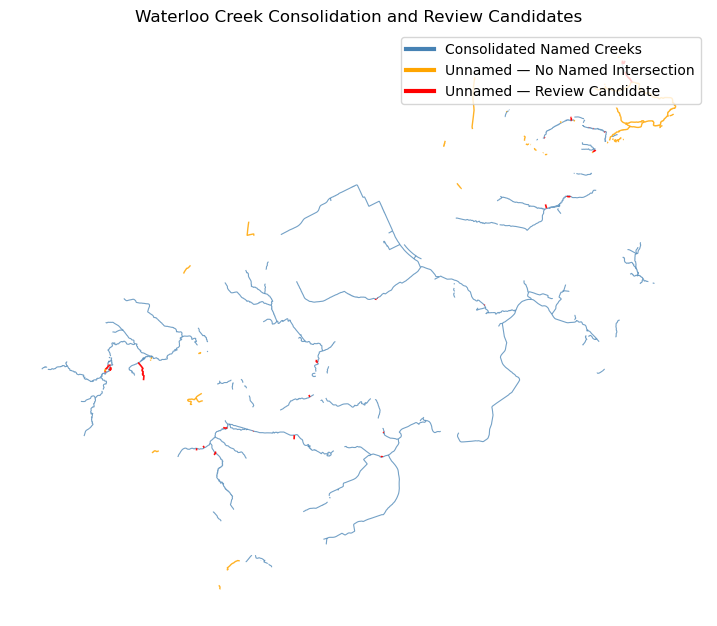

In [142]:
from matplotlib.lines import Line2D

# ============================================================
# Visualize Waterloo Creek Consolidation
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9)
)

waterloo_creeks_named_consolidated.plot(
    ax=ax,
    color="steelblue",
    edgecolor="navy",
    linewidth=0.8,
    alpha=0.75
)

waterloo_creeks_unnamed.loc[
    waterloo_creeks_unnamed[
        "Review Status"
    ] == "No intersection with named creek"
].plot(
    ax=ax,
    color="orange",
    edgecolor="darkorange",
    linewidth=1.0,
    alpha=0.85
)

waterloo_creeks_unnamed.loc[
    waterloo_creeks_unnamed[
        "Review Status"
    ] == "Intersects named creek — review required"
].plot(
    ax=ax,
    color="red",
    edgecolor="darkred",
    linewidth=1.2,
    alpha=0.95
)

legend_elements = [
    Line2D(
        [0],
        [0],
        color="steelblue",
        lw=3,
        label="Consolidated Named Creeks"
    ),
    Line2D(
        [0],
        [0],
        color="orange",
        lw=3,
        label="Unnamed — No Named Intersection"
    ),
    Line2D(
        [0],
        [0],
        color="red",
        lw=3,
        label="Unnamed — Review Candidate"
    )
]

ax.legend(
    handles=legend_elements,
    loc="best"
)

ax.set_title(
    "Waterloo Creek Consolidation and Review Candidates"
)

ax.set_axis_off()

plt.show()

#### 10.6.9 Interim Working Dataset

This recombines the safely consolidated named creeks with all preserved unnamed records. It does not merge any review candidates into named creeks.

In [143]:
# ============================================================
# Recombine Waterloo Creek Working Dataset
# ============================================================

waterloo_creeks_consolidated = gpd.GeoDataFrame(
    pd.concat(
        [
            waterloo_creeks_named_consolidated,
            waterloo_creeks_unnamed
        ],
        ignore_index=True,
        sort=False
    ),
    geometry="geometry",
    crs=waterloo_creeks.crs
)

waterloo_creeks_consolidated.geometry = (
    waterloo_creeks_consolidated
    .geometry
    .make_valid()
)

print(
    "Final working Waterloo creek features:",
    len(waterloo_creeks_consolidated)
)

Final working Waterloo creek features: 118


### 10.6.10 Interpretation

The name-based consolidation safely reduces segmentation among identified Waterloo creeks while preserving every unnamed record.

Unnamed geometries that intersect named creeks are not automatically treated as missing creek segments. They may instead represent tributaries, branches, drainage channels, or other independently mapped features. These records are therefore flagged as candidates for manual review.

The review table preserves each feature's original `OBJECTID`, allowing uncertain records to be located in the source GeoHub and compared against surrounding geometries. Where manual inspection confirms that an unnamed record belongs to a named creek, its `OBJECTID` can later be added to an explicit correction list.

This approach creates a clear distinction between:

- automatic, evidence-based consolidation,
- geometric candidate detection,
- human-confirmed corrections.

No uncertain geometries are merged during this stage.